#  step1: bussiness problem understanding

# description

* to develop a machine learning regression model that predicts the price of a house based on features such as bedrooms, bathrooms, living area, lot size, floors, waterfront, view, condition, location, and year built.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# step 2: data collection

In [22]:
df=pd.read_csv(r"C:\Users\nages\Downloads\house_prices_dataset (1).csv")
df

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903
...,...,...,...,...,...
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379


# --> data understanding

* The house price dataset contains information about houses and their selling prices. The data includes property features such as number of rooms,age,square feet,price

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [24]:
df.shape

(10000, 5)

In [25]:
df.size

50000

# step3: data preprocessing

# --> eda(exploratation data analysis)

*  **Data Exploration:** Understanding the dataset’s structure, features, data types, and basic statistical information before analysis.


In [26]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


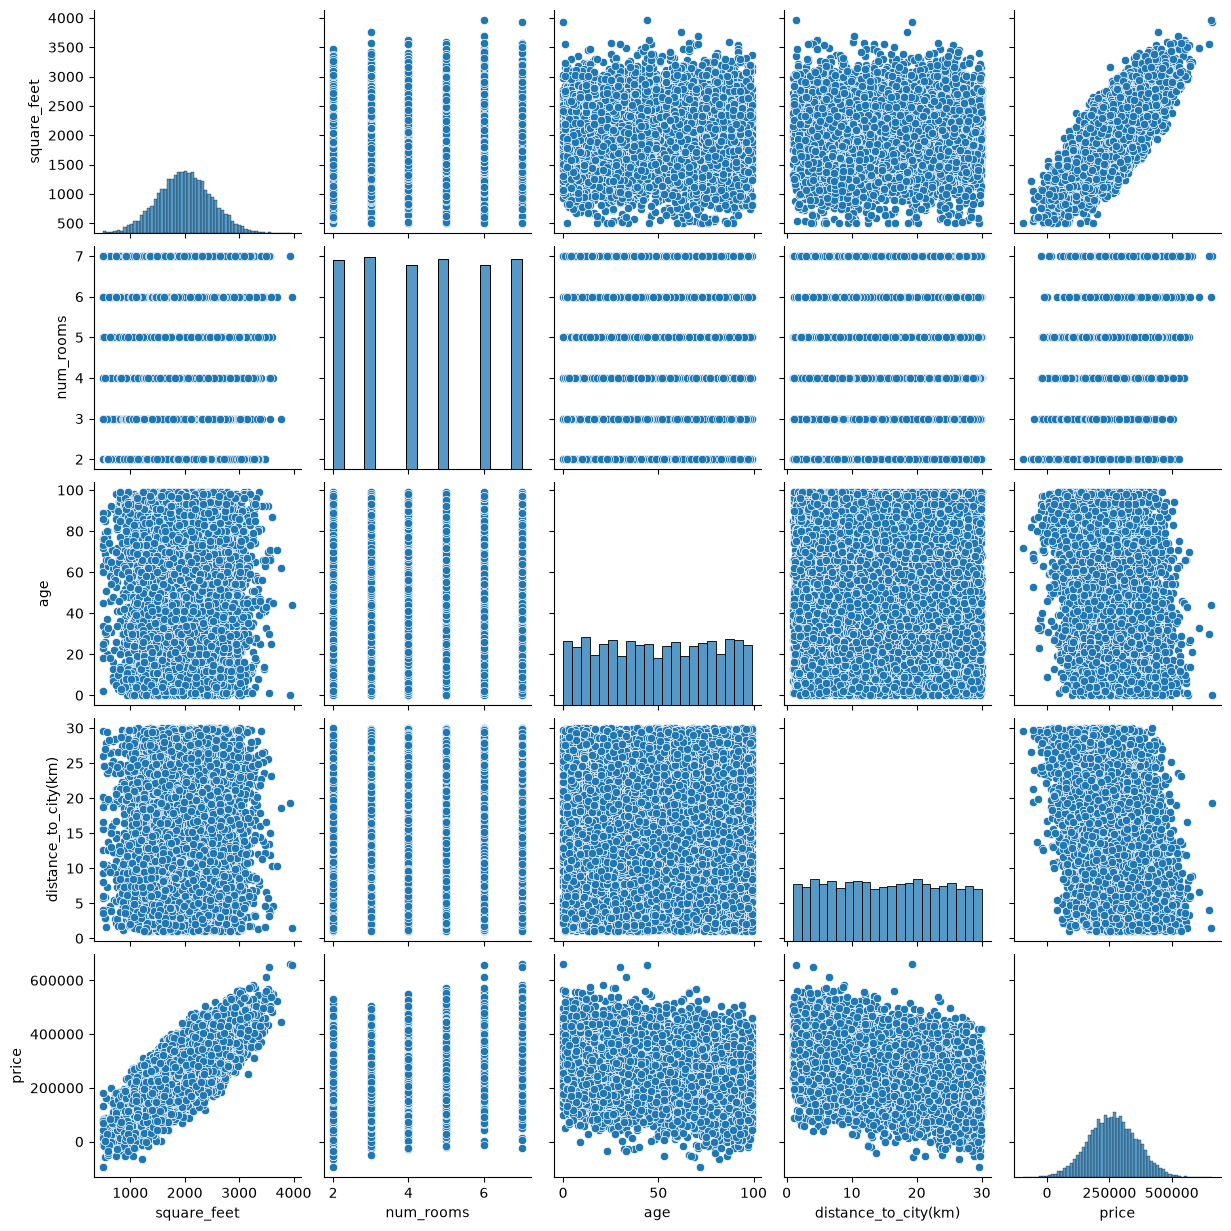

In [27]:
sns.pairplot(df)
plt.show()

In [28]:
df.corr()

,square_feet,num_rooms,age,distance_to_city(km),price
square_feet,1.000000,-0.006982,0.009760,0.004638,0.756545
num_rooms,-0.006982,1.000000,0.005636,0.016747,0.335230
age,0.009760,0.005636,1.000000,0.011175,-0.290799
distance_to_city(km),0.004638,0.016747,0.011175,1.000000,-0.418217
price,0.756545,0.335230,-0.290799,-0.418217,1.000000


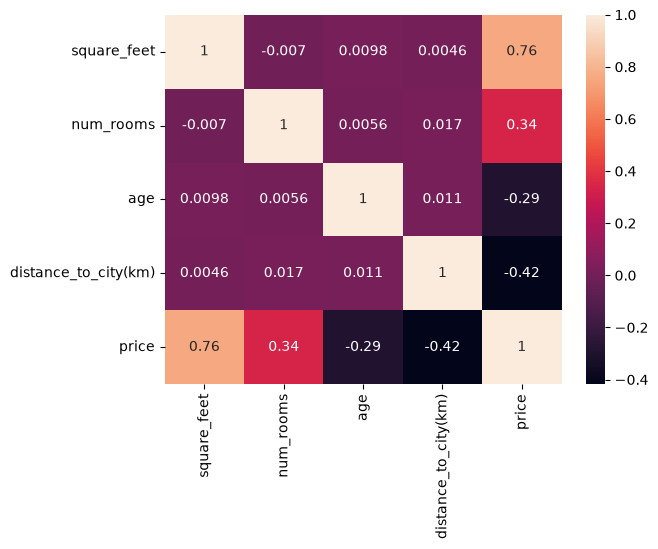

In [29]:
sns.heatmap(df.corr(),annot=True)
plt.show()

#  step3: data cleaning

In [30]:
df.isnull().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

# step4: data wrangling

In [31]:
# encoding is not required beacause there is no categorical columns

# --> x&y

In [32]:
X = df[['square_feet', 'num_rooms', 'age', 'distance_to_city(km)']]
y = df['price']

# -->train-test split 

In [33]:
x= df.drop('price', axis=1)
y = df['price']

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

# step 4: modeling

In [35]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 149.77,20104.72,-1002.85,-4990.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['square_feet','num_rooms','age','distance_to_city(km)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-545.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [36]:
model.intercept_ # constant

np.float64(-545.4118352716905)

In [37]:
model.coef_ #change of input

array([  149.77279229, 20104.71808184, -1002.8541624 , -4990.42332154])

# --> predictions

In [38]:
train_predictions=model.predict(x_train)

In [39]:
test_predictions=model.predict(x_test)

# step 5: evalution

In [40]:
from sklearn.metrics import mean_absolute_error #average prediction error
print("MAE for test data:",mean_absolute_error(y_test,test_predictions))
print("MAE for train data:",mean_absolute_error(y_train,train_predictions))

MAE for test data: 15680.10523734952
MAE for train data: 16184.302132995215


In [41]:
from sklearn.metrics import mean_squared_error ##average squared error
print("MSE for test data:",mean_squared_error(y_test,test_predictions))
print("MSE for train data:",mean_squared_error(y_train,train_predictions))

MSE for test data: 388320995.09551287
MSE for train data: 408795377.21214616


In [42]:
test_RMSE=np.sqrt(mean_squared_error(y_test,test_predictions)) #square root of MSE
train_RMSE=np.sqrt(mean_squared_error(y_train,train_predictions))
print(train_RMSE,test_RMSE)

20218.688810408705 19705.8619475402


In [43]:
from sklearn.metrics import r2_score
print("R2 for test data:",r2_score(y_test,test_predictions))
print("R2 for test data:",r2_score(y_train,train_predictions))

R2 for test data: 0.9605138600153437
R2 for test data: 0.9574066421504598


In [44]:
model.score(x_train,y_train)  

0.9574066421504598

In [45]:
model.score(x_test,y_test)  

0.9605138600153437

# checklist

In [46]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)
scores.mean()

[0.95768187 0.95851935 0.95421269 0.96006465 0.96083127]


np.float64(0.958261966015414)

# check for assumptions

# 1 linearity of errors

In [47]:
test_res=y_test-test_predictions

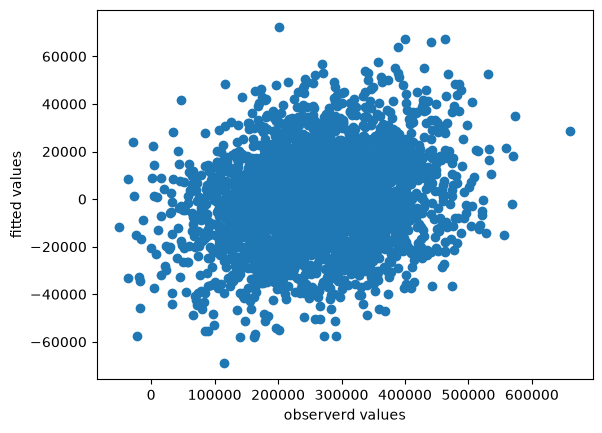

In [48]:
plt.scatter(y_test,test_res)
plt.xlabel("observerd values")
plt.ylabel("fitted values")
plt.show()

# 2 normality of errors

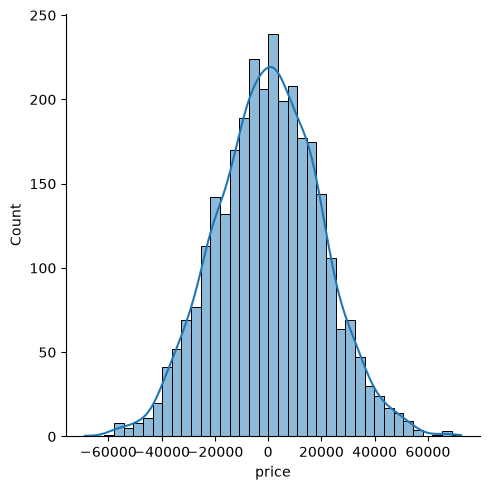

In [49]:
sns.displot(test_res,kde=True)
plt.show()

* “This histogram shows the distribution of the price variable. Most observations are concentrated around zero to 20,000, and the distribution is approximately bell-shaped. There are fewer observations toward the extreme positive and negative values. I would also investigate the negative price values because they may indicate data-quality issues.”

# 3 equalance of errors

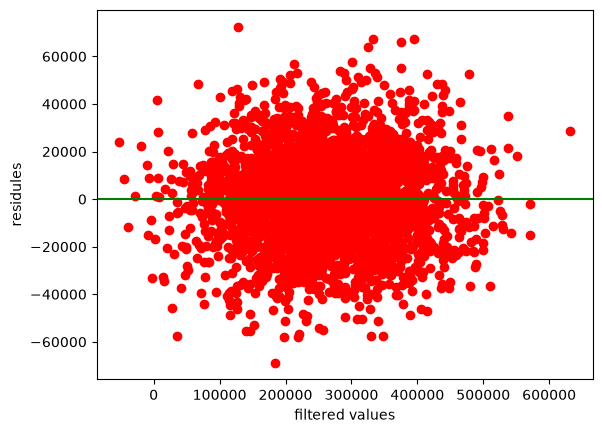

In [50]:
plt.scatter(test_predictions,test_res,c="r")
plt.axhline(y=0,color="green")
plt.xlabel("filtered values")
plt.ylabel("residules")
plt.show()

* The residuals are mostly randomly scattered around zero, with no clear pattern or curve. This suggests the linear model is reasonably appropriate.

# 4 variance of significance

In [51]:
import statsmodels.formula.api as smf
model2=smf.ols("y~x",data=df).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                 5.751e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:27:21   Log-Likelihood:            -1.1326e+05
No. Observations:               10000   AIC:                         2.265e+05
Df Residuals:                    9995   BIC:                         2.266e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -321.7234   1095.994     -0.294      0.769   -2470.093    1826.646
x[0]         149.9204      0.401    374.206      0.000     149.135     150.706
x[1]        2.008e+04    117.316    171.124      0.000    1.98e+04    2.03e+04
x[2]       -1002.2208      6.924   -144.751      0.000   -1015.793    -988.649
x[3]       -5011.9649     24.114   -207.843      0.000   -5059.234   -4964.696
==============================================================================
Omnibus:                        0.055   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.973   Jarque-Bera (JB):                0.051
Skew:                           0.005   Prob(JB):                        0.975
Kurtosis:                       3.002   Cond. No.                     1.13e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

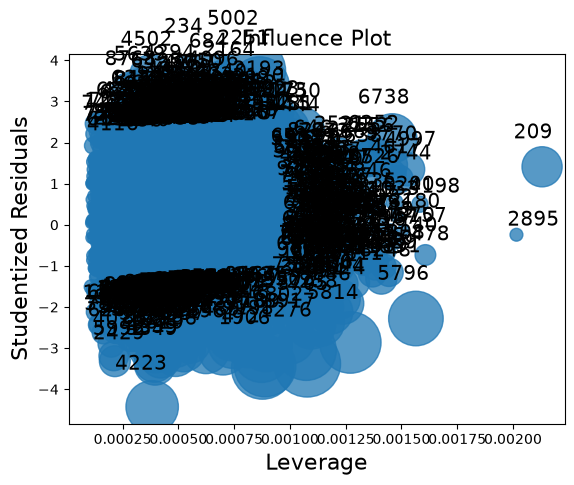

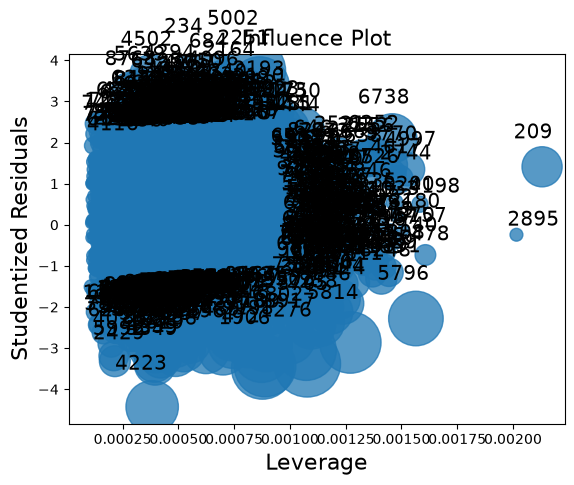

In [52]:
import statsmodels.api as sm
sm.graphics.influence_plot(model2)

In [53]:
df_new=df.drop(df.index[[265]],axis=0)
df_new

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903
...,...,...,...,...,...
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379


In [54]:
df_new = df_new.rename(columns={'distance_to_city(km)': 'distance'})

In [55]:
lm=smf.ols(formula='price ~ square_feet + num_rooms + age +distance',data=df_new).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                 5.754e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:27:49   Log-Likelihood:            -1.1324e+05
No. Observations:                9999   AIC:                         2.265e+05
Df Residuals:                    9994   BIC:                         2.265e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -329.1332   1095.739     -0.300      0.764   -2477.002    1818.736
square_feet   149.9324      0.401    374.296      0.000     149.147     150.718
num_rooms    2.007e+04    117.293    171.138      0.000    1.98e+04    2.03e+04
age         -1002.2110      6.922   -144.784      0.000   -1015.780    -988.642
distance    -5012.6795     24.110   -207.906      0.000   -5059.941   -4965.418
==============================================================================
Omnibus:                        0.044   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.978   Jarque-Bera (JB):                0.040
Skew:                           0.005   Prob(JB):                        0.980
Kurtosis:                       3.002   Cond. No.                     1.13e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# variance inflation factor

In [56]:
rsq_square = smf.ols('square_feet ~ num_rooms + age + distance',data=df_new).fit()
rsq_square.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            square_feet   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5538
Date:                Wed, 30 Sep 2026   Prob (F-statistic):              0.646
Time:                        22:27:49   Log-Likelihood:                -76347.
No. Observations:                9999   AIC:                         1.527e+05
Df Residuals:                    9995   BIC:                         1.527e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1995.6605     18.713    106.647      0.000    1958.980    2032.341
num_rooms     -2.0520      2.929     -0.701      0.484      -7.793       3.689
age            0.1683      0.173      0.974      0.330      -0.170       0.507
distance       0.2890      0.602      0.480      0.631      -0.891       1.469
==============================================================================
Omnibus:                        0.452   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.798   Jarque-Bera (JB):                0.474
Skew:                           0.015   Prob(JB):                        0.789
Kurtosis:                       2.983   Cond. No.                         222.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [57]:
rsq_square = smf.ols('square_feet ~ num_rooms + age + distance', data=df_new).fit().rsquared
vif_square = 1/(1-rsq_square)

rsq_num = smf.ols('num_rooms ~ square_feet + age + distance', data=df_new).fit().rsquared
vif_num = 1/(1-rsq_num)

rsq_age = smf.ols('age ~ square_feet + num_rooms + distance', data=df_new).fit().rsquared
vif_age = 1/(1-rsq_age)

rsq_distance = smf.ols('distance ~ square_feet + num_rooms + age', data=df_new).fit().rsquared
vif_distance = 1/(1-rsq_distance)

In [58]:
d1 = {'variables': ['square_feet', 'num_rooms', 'age', 'distance'],'VIF': [vif_square, vif_num, vif_age, vif_distance]}
vif_frame = pd.DataFrame(d1)
vif_frame

,variables,VIF
0,square_feet,1.000166
1,num_rooms,1.000356
2,age,1.000250
3,distance,1.000423


# save the model

In [59]:
from joblib import dump

In [60]:
dump(model,'price_model.joblib')

['price_model.joblib']

# load the model

In [61]:
from joblib import load

In [62]:
loaded_model=load('price_model.joblib')

In [63]:
loaded_model.predict([[30000,20000,10000,40000]])

C:\Users\nages\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.96941526e+08])